In [2]:
!apt-get update
!apt-get install -y libsndfile1

'apt-get' is not recognized as an internal or external command,
operable program or batch file.
'apt-get' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import pandas as pd
import numpy as np

import os
import sys

# librosa is a Python library for analyzing audio and music. It can be used to extract the data from the audio files we will see it later.
import librosa


import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# to play the audio files
from IPython.display import Audio


from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [4]:
!pip install tensorflow


In [5]:
!pip install keras


In [6]:
#Data Preparation
#Data Preparation

# Paths for data.
Ravdess = "C:/Users/Asale/Desktop/Real-Time-Speech-Emotion-Recognition-master/serdataset/"
Tess = "C:/Users/Asale/Desktop/Real-Time-Speech-Emotion-Recognition-master/TESS Toronto emotional speech set data/"
Savee =  "C:/Users/Asale/Desktop/Real-Time-Speech-Emotion-Recognition-master/ALL/"


In [7]:
#Ravdess dataset
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    # as their are 20 different actors in our previous directory we need to extract files for each actor.
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        # third part in each file represents the emotion associated to that file.
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# changing integers to actual emotions.
Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)
Ravdess_df.head()



,Emotions,Path
0,neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
1,neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
2,neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
3,neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
4,calm,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...


In [8]:
#TESS dataset
tess_directory_list = os.listdir(Tess)

file_emotion = []
file_path = []


for dir_name in tess_directory_list:
    # Construct the full path to the directory
    directory_path = os.path.join(Tess, dir_name)
    
    # Check if this path is indeed a directory
    if os.path.isdir(directory_path):
        # List all files in this directory
        files = os.listdir(directory_path)
        for file_name in files:
            # Process each file
            if file_name.lower().endswith('.wav'):  # Check if the file is a WAV file
                # Extract the emotion from the filename
                parts = file_name.split('_')
                if len(parts) > 2:
                    emotion = parts[2].split('.')[0]
                    if emotion == 'ps':
                        emotion = 'surprise'
                    file_emotion.append(emotion)
                    file_path.append(os.path.join(directory_path, file_name))
                else:
                    print(f"Unexpected file format: {file_name}")
    else:
        print(f"Expected a directory but found a file: {directory_path}")



        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Tess_df = pd.concat([emotion_df, path_df], axis=1)
Tess_df.head()

Unexpected file format: 03-01-02-02-01-01-01.wav


,Emotions,Path
0,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
1,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
2,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
3,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
4,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...


In [9]:
#savee dataset 

savee_directory_list = os.listdir(Savee)

file_emotion = []
file_path = []

for file in savee_directory_list:
    file_path.append(Savee + file)
    part = file.split('_')[1]
    ele = part[:-6]
    if ele=='a':
        file_emotion.append('angry')
    elif ele=='d':
        file_emotion.append('disgust')
    elif ele=='f':
        file_emotion.append('fear')
    elif ele=='h':
        file_emotion.append('happy')
    elif ele=='n':
        file_emotion.append('neutral')
    elif ele=='sa':
        file_emotion.append('sad')
    else:
        file_emotion.append('surprise')

# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Savee_df = pd.concat([emotion_df, path_df], axis=1)
Savee_df.head()

,Emotions,Path
0,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
1,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
2,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
3,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
4,angry,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...


In [10]:
# creating Dataframe using all the 4 dataframes we created so far.
# data_path = pd.concat([Ravdess_df, Crema_df, Tess_df, Savee_df], axis = 0)
data_path = pd.concat([Ravdess_df , Tess_df , Savee_df], axis = 0)


#Filter Out Unwanted Emotions:
data_path = data_path[data_path['Emotions'].isin(['fear', 'happy', 'calm', 'neutral'])]
#Combine 'Calm' and 'Neutral'
data_path['Emotions'] = data_path['Emotions'].replace({'calm': 'calm_neutral', 'neutral': 'calm_neutral'})


data_path.to_csv("data_path.csv",index=False)
data_path.shape #2D array with 4240 rows and 2 columns,

(2112, 2)

In [11]:
#Data Visualisation and Exploration¶

data_path.head()


,Emotions,Path
0,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
1,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
2,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
3,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
4,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...


In [12]:
#Data Augmentation

def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, n_steps=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=n_steps)

# taking any example and checking for techniques.
path = np.array(data_path.Path)[1] #accese to the path which is the sec col [1]
data, sample_rate = librosa.load(path)
#The data and sample_rate can then be used for tasks such as audio feature extraction, visualization, or audio playback.

AttributeError: '_process_plot_var_args' object has no attribute 'prop_cycler'

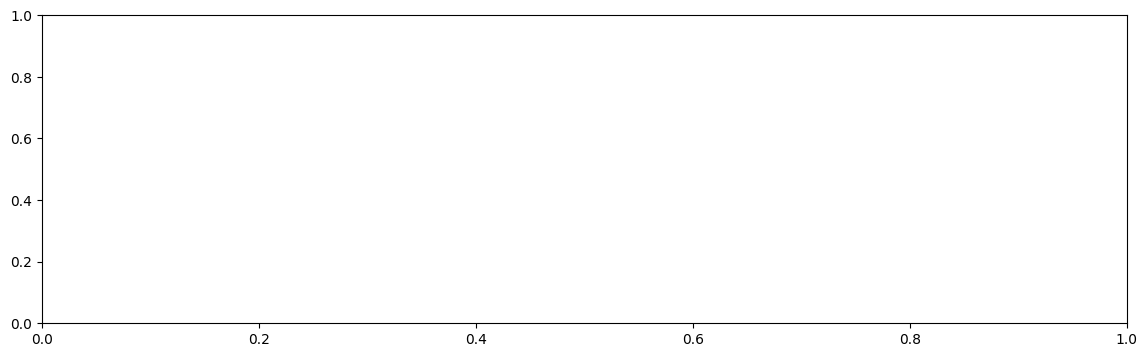

In [13]:
#1. Simple Audio
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=data, sr=sample_rate)
Audio(path)

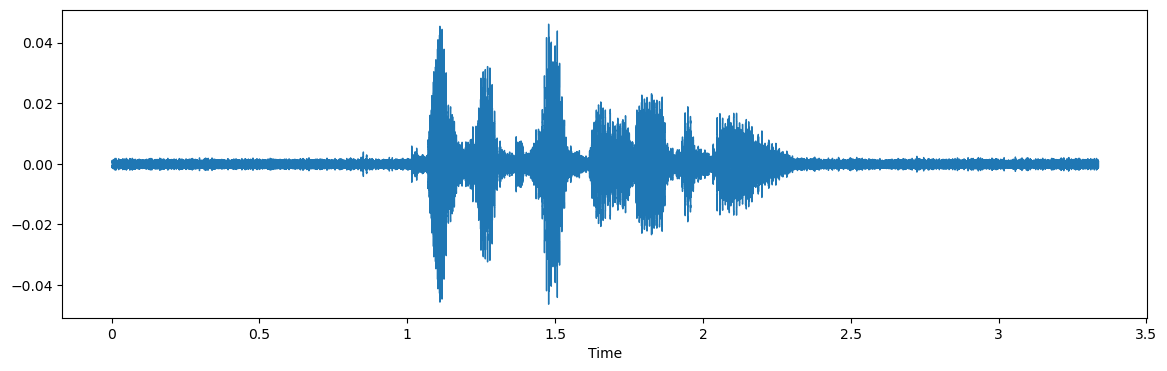

In [ ]:
#Noise Injection
x = noise(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

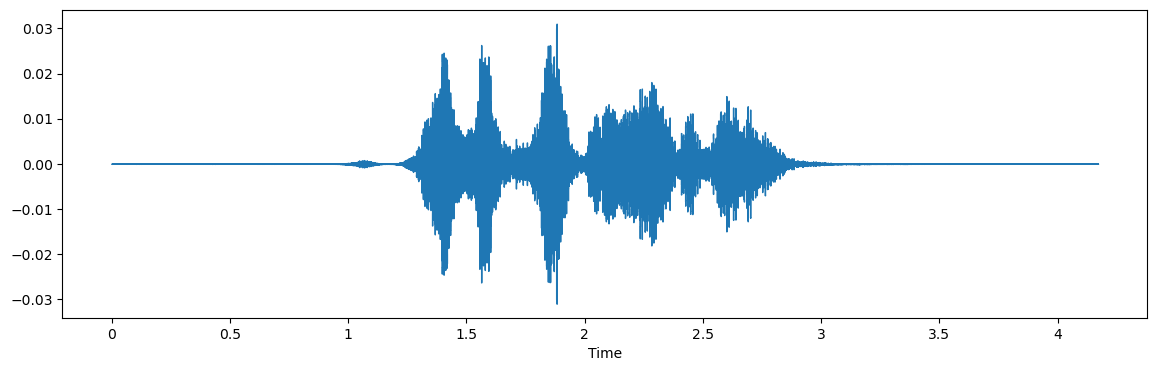

In [ ]:
#3. Stretching
x = stretch(data, rate=0.8)#rate: the speed of the audio; values less than 1.0 will slow it down, while values greater than 1.0 will speed it up.
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

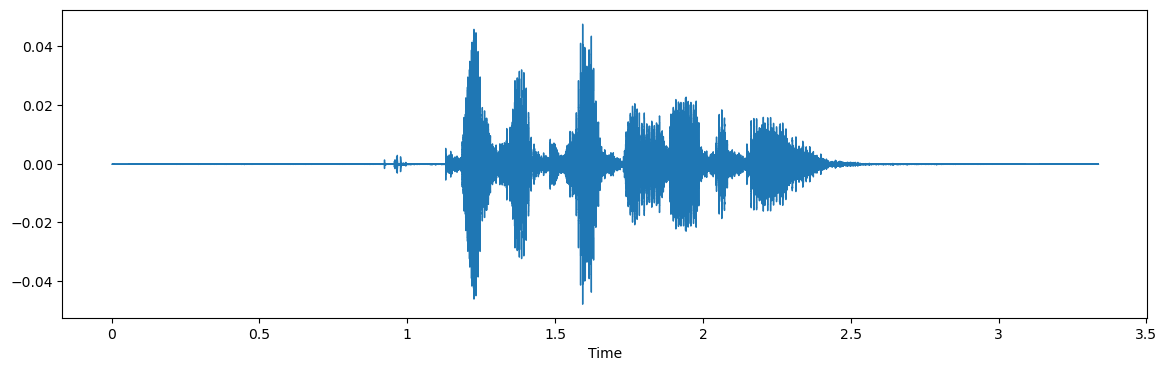

In [ ]:
#4. Shifting
x = shift(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

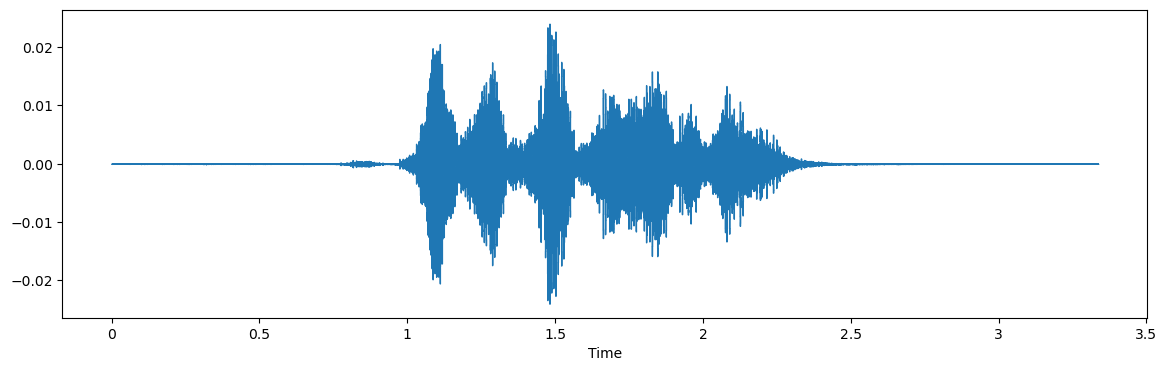

In [ ]:
#5. Pitch
x = pitch(data, sample_rate, n_steps=0.7)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

In [13]:
#Feature Extraction
def extract_features(data):
    # ZCR
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result=np.hstack((result, zcr)) # stacking horizontally

    # Chroma_stft
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft)) # stacking horizontally

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc)) # stacking horizontally

    # Root Mean Square Value
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms)) # stacking horizontally
  # MelSpectogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel)) # stacking horizontally
    
    return result

def get_features(path):
    #print('path.shape in get_features function: ' , path.shape)
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)
    
    # without augmentation
    res1 = extract_features(data)
    print('res1.shape in res1 = extract_features(data): ' , res1.shape)#(162,)
    #print('res1:',res1)
    result = np.array(res1) #converts res1 into a NumPy array
    print('result',result.shape)#(162,)
    
    # data with noise
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically
    # data with stretching and pitching
    new_data = stretch(data)
    data_stretch_pitch = pitch(new_data, sample_rate)
    res3 = extract_features(data_stretch_pitch)
    result = np.vstack((result, res3)) # stacking vertically
    
    return result

In [14]:
print(data_path.shape)
data_path.head()

(2112, 2)


,Emotions,Path
0,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
1,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
2,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
3,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...
4,calm_neutral,C:/Users/Asale/Desktop/Real-Time-Speech-Emotio...


In [15]:
data_path['Emotions'].value_counts()


Emotions
calm_neutral    808
happy           652
fear            652
Name: count, dtype: int64

In [16]:
X, Y = [], [] # X: store the features extracted from the audio files, Y: store the corresponding labels (emotions).
for path, emotion in zip(data_path.Path, data_path.Emotions): #pairs each path with its corresponding emotion label, to process them together in the loop.
    print(path," : ",emotion)
    feature = get_features(path)
    #print('feature in x,y: ',feature)
    for ele in feature:
        X.append(ele) #Each element of the extracted features is appended to the X list.
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(emotion) #The corresponding emotion label is appended to the Y list.

C:/Users/Asale/Desktop/Real-Time-Speech-Emotion-Recognition-master/serdataset/Actor_01/03-01-01-01-01-01-01.wav  :  calm_neutral
res1.shape in res1 = extract_features(data):  (162,)
result (162,)
C:/Users/Asale/Desktop/Real-Time-Speech-Emotion-Recognition-master/serdataset/Actor_01/03-01-01-01-01-02-01.wav  :  calm_neutral
res1.shape in res1 = extract_features(data):  (162,)
result (162,)
C:/Users/Asale/Desktop/Real-Time-Speech-Emotion-Recognition-master/serdataset/Actor_01/03-01-01-01-02-01-01.wav  :  calm_neutral
res1.shape in res1 = extract_features(data):  (162,)
result (162,)
C:/Users/Asale/Desktop/Real-Time-Speech-Emotion-Recognition-master/serdataset/Actor_01/03-01-01-01-02-02-01.wav  :  calm_neutral
res1.shape in res1 = extract_features(data):  (162,)
result (162,)
C:/Users/Asale/Desktop/Real-Time-Speech-Emotion-Recognition-master/serdataset/Actor_01/03-01-02-01-01-01-01.wav  :  calm_neutral
res1.shape in res1 = extract_features(data):  (162,)
result (162,)
C:/Users/Asale/Deskt

In [17]:
len(X), len(Y), data_path.Path.shape


(6336, 6336, (2112,))

In [18]:
Features = pd.DataFrame(X) #creates a pandas DataFrame named Features from the list X.
Features['labels'] = Y #adds a new column named 'labels' to the DataFrame Features
Features.to_csv('features.csv', index=False) #exports the DataFrame Features to a CSV file named 'features.csv'.
#index=False parameter is used to indicate that the DataFrame's index (row numbers) should not be written to the CSV file.
Features.head()

,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.252405,0.667188,0.695764,0.667365,0.675234,0.698576,0.686025,0.706901,0.749484,0.782826,...,2.438158e-16,1.668009e-16,1.217045e-16,1.040694e-16,1.001666e-16,1.068984e-16,2.113795e-16,2.461139e-16,8.922675e-17,calm_neutral
1,0.336995,0.791274,0.838027,0.829394,0.824559,0.833310,0.772569,0.685922,0.711568,0.757471,...,1.475417e-04,1.422721e-04,1.456744e-04,1.405817e-04,1.507940e-04,1.487959e-04,1.414907e-04,1.430697e-04,1.449425e-04,calm_neutral
2,0.162746,0.612493,0.636828,0.680770,0.637071,0.597723,0.644233,0.677131,0.701447,0.719361,...,1.212861e-16,7.743417e-17,6.601077e-17,4.748784e-17,4.574484e-17,4.674683e-17,4.954091e-17,3.286728e-17,1.173569e-17,calm_neutral
3,0.218682,0.653719,0.695061,0.668355,0.653044,0.691417,0.691495,0.686064,0.738047,0.762083,...,4.833390e-17,3.569633e-17,3.280019e-17,4.279843e-17,5.439183e-17,7.460605e-17,2.295677e-16,2.263401e-16,6.190976e-17,calm_neutral
4,0.326068,0.791793,0.826666,0.802963,0.784504,0.795718,0.727720,0.652372,0.709500,0.756164,...,1.033577e-04,9.897124e-05,9.837460e-05,9.487904e-05,9.741593e-05,1.035794e-04,1.059856e-04,1.085341e-04,1.057040e-04,calm_neutral


In [19]:
#Data Preparation

#iloc[:, :-1] is a way to select data from the DataFrame:
# : means "select all rows".
# :-1 means "select all columns except the last one".
X = Features.iloc[: ,:-1].values # X contains the features (independent variables) used to predict an outcome
print(X.shape) #Each row in X represents an audio file, Each column in X represents a different feature extracted for each audio

#selecting the 'labels' column from the DataFrame Features
#.values again converts the selected Series (a single column from a DataFrame) into a NumPy array.
Y = Features['labels'].values # Y contains the target (dependent variable) that you're trying to predict.
print(Y.shape)# Each element in Y corresponds to a label for each instance(audio file)


(6336, 162)
(6336,)


In [20]:
# As this is a multiclass classification problem onehotencoding our Y.

# OneHotEncoder is a utility from the scikit-learn library, used for encoding categorical features as a one-hot numeric array, to provided to machine learning algorithms.
# Each unique category (emotion) in your data will be represented as a binary vector, where only the position corresponding to the specific category is 1, and all other positions are 0
encoder = OneHotEncoder()

#reshapes this array into a 2D array with one column, because OneHotEncoder expects a 2D array as input.
#The -1 in the reshape function is a placeholder that tells NumPy to automatically calculate the number of rows.
#"Fitting" the encoder means determining the unique categories (emotions) happy,fear,..
#Transforming:creates a binary vector and give a value for each position ex: [1, 0, 0] , # of element = #emotion
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()
#Now, Y no longer contains the original categorical labels. Instead, it contains the one-hot encoded representations of these labels.

In [21]:
# splitting data
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((4752, 162), (4752, 3), (1584, 162), (1584, 3))

In [22]:
# scaling our data with sklearn's Standard scaler
scaler = StandardScaler()
#fit part of fit_transform computes the mean and standard deviation for each feature in x_train.
#transform part then scales the x_train data using these computed values (i.e., subtracting the mean from each feature and then dividing by the standard deviation).
x_train = scaler.fit_transform(x_train)

#Note that only transform (and not fit_transform) is used here. This is because the scaling parameters (mean and standard deviation) are learned from the training data and then applied to the test data. This ensures that both datasets are scaled in the same way.
#x_test is scaled using the mean and standard deviation computed from x_train.
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape


#When predicting a new audio file, only use the transform 

((4752, 162), (4752, 3), (1584, 162), (1584, 3))

In [23]:
x_train.shape


(4752, 162)

In [24]:
# reshape to making our data compatible to model.

#np.expand_dims is a NumPy function used to expand the shape of an array. It adds an additional dimension at the specified axis.
#axis=2 indicates that the new dimension should be added as the third dimension (since axis indexing starts at 0).
#CNNs often expect data to be in the shape 

x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

#when predicting a new audio file, you should reshape it like this

((4752, 162, 1), (4752, 3), (1584, 162, 1), (1584, 3))

In [25]:
#modilng (convolutional neural network (CNN) )
model=Sequential() #creating a model where each layer has exactly one input tensor and one output tensor.
#First Convolutional Layer
#is a 1D convolution layer with 256 filters.
#kernel_size=5 means the convolution window will include 5 units at a time.
#strides=1 indicates that the convolution will move one unit at a time across the input.
#padding='same' ensures that the output size is the same as the input size by adding padding if necessary.
#input_shape=(x_train.shape[1], 1) defines the shape of the input data, where x_train.shape[1] is the number of features in the input data.

model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)))

#First Pooling Layer
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))
model.add(Dropout(0.2)) #Dropout is a regularization technique where randomly selected neurons are ignored during training, which helps in preventing overfitting.

model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Flatten())
model.add(Dense(units=32, activation='relu'))#A fully connected layer with 32 neurons and ReLU activation function.
model.add(Dropout(0.3))
model.add(Dense(units=3, activation='softmax'))#change to 3 (3 emotions)
model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

model.summary()

#Each type of layer has a specific function in the model, like feature extraction (convolutional layers), dimensionality reduction (pooling layers), preventing overfitting (dropout layers), and making predictions (dense layers).





Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 162, 256)          1536      
                                                                 
 max_pooling1d (MaxPooling1  (None, 81, 256)           0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 81, 256)           327936    
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 41, 256)           0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 41, 128)           163968    
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 21, 128)         

In [26]:
rlrp = ReduceLROnPlateau(monitor='loss', factor=0.4, verbose=0, patience=2, min_lr=0.0000001)
history=model.fit(x_train, y_train, batch_size=64, epochs=50, validation_data=(x_test, y_test), callbacks=[rlrp])

Epoch 1/50


75/75 [==============================] - 9s 79ms/step - loss: 0.8636 - accuracy: 0.5823 - val_loss: 0.5976 - val_accuracy: 0.7854 - lr: 0.0010
Epoch 2/50
75/75 [==============================] - 5s 73ms/step - loss: 0.5538 - accuracy: 0.7670 - val_loss: 0.3985 - val_accuracy: 0.8504 - lr: 0.0010
Epoch 3/50
75/75 [==============================] - 7s 89ms/step - loss: 0.4324 - accuracy: 0.8213 - val_loss: 0.3008 - val_accuracy: 0.8807 - lr: 0.0010
Epoch 4/50
75/75 [==============================] - 7s 97ms/step - loss: 0.3813 - accuracy: 0.8390 - val_loss: 0.2895 - val_accuracy: 0.8864 - lr: 0.0010
Epoch 5/50
75/75 [==============================] - 7s 95ms/step - loss: 0.3229 - accuracy: 0.8609 - val_loss: 0.2987 - val_accuracy: 0.8845 - lr: 0.0010
Epoch 6/50
75/75 [==============================] - 7s 96ms/step - loss: 0.2982 - accuracy: 0.8773 - val_loss: 0.2869 - val_accuracy: 0.8718 - lr: 0.0010
Epoch 7/50
75/75 [==============================] - 7s 96ms/step - loss: 0

50/50 [==============================] - 1s 17ms/step - loss: 0.2265 - accuracy: 0.9539
Accuracy of our model on test data :  95.39141654968262 %


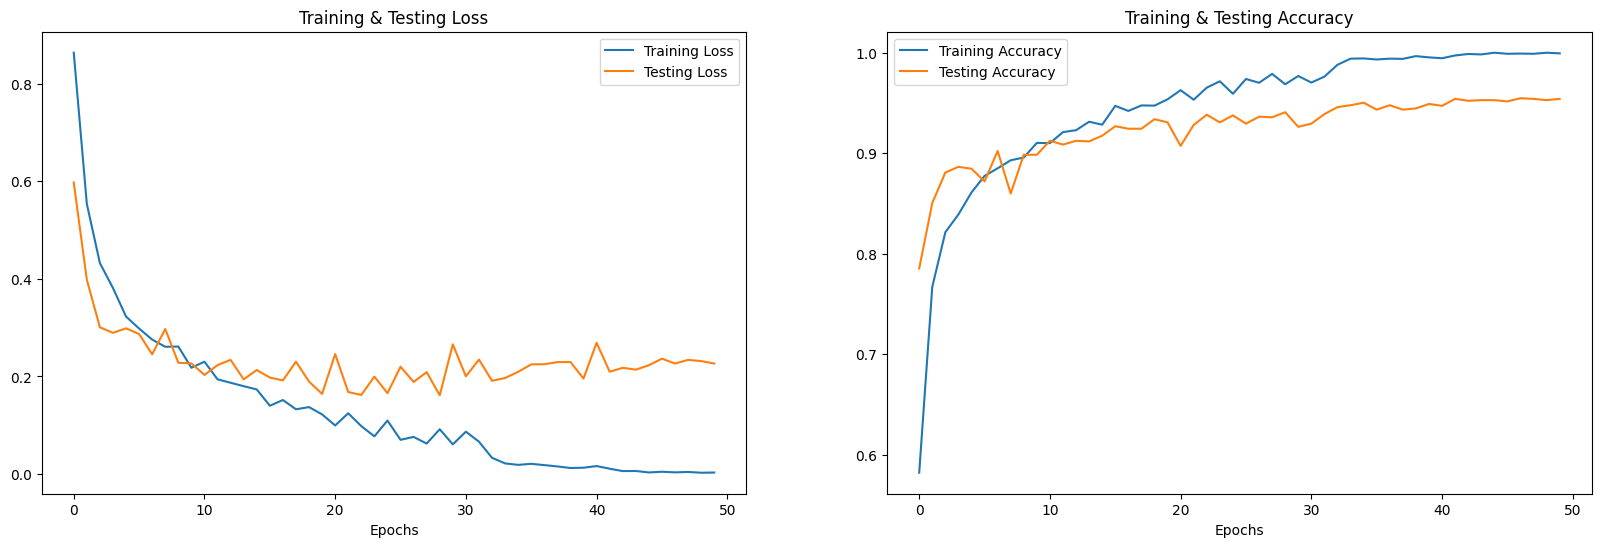

In [27]:
print("Accuracy of our model on test data : " , model.evaluate(x_test,y_test)[1]*100 , "%")

epochs = [i for i in range(50)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")


ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [33]:
# to save model 
import pickle
with open ('SER0_save_model','wb') as f:
    pickle.dump(model,f)

In [34]:
with open ('SER0_save_model','rb') as f:
    model_SER0=pickle.load(f)


In [29]:
# predicting on test data.
pred_test = model.predict(x_test)
y_pred = encoder.inverse_transform(pred_test)

y_test = encoder.inverse_transform(y_test)

50/50 [==============================] - 1s 14ms/step


In [31]:
df = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df['Predicted Labels'] = y_pred.flatten()#.flatten() is used to convert y_pred into a 1-dimensional array if it is not already. 
df['Actual Labels'] = y_test.flatten()

df.head(20)

,Predicted Labels,Actual Labels
0,calm_neutral,calm_neutral
1,fear,fear
2,fear,fear
3,calm_neutral,calm_neutral
4,happy,happy
5,calm_neutral,calm_neutral
6,calm_neutral,fear
7,happy,happy
8,calm_neutral,calm_neutral
9,calm_neutral,calm_neutral


In [32]:
def predict_emotion(audio_file):
    # Extract features from the audio file
    features = get_features(audio_file)
    print('in predict features:' , features.shape)#3 becuse: in get_features function is applying three different audio processing techniques to each file: Original audio (res1).Audio with added noise (res2).Audio with stretching and pitching (res3).
    #print(features.head)

    # Reshape the features to match the input of scaling
    #features_2d = features.np.atleast_2d(features)
    #print('features_2d:' , features_2d.shape)
    #reshape(1, -1)#cuse crach for the kernal

    #scaling
    scaled_new_features = scaler.transform( features )
    print('scaled_new_featuresd:' , scaled_new_features.shape)

    
    # Reshape to match the input of the model
    re_mo = np.expand_dims(scaled_new_features, axis=2)
    print('re_mo:' , re_mo.shape)


    # Predict the emotion using the loaded model
    pre = model.predict(re_mo)
    print('pre' , pre)


    predicted_label_index = np.argmax(pre, axis=1)
    print(predicted_label_index)#[5 1 5]

    lab1 = max(predicted_label_index)
    print('max: ',lab1)

    predicted_label_onehot = to_categorical(lab1, num_classes=3)

    fin = encoder.inverse_transform(predicted_label_onehot.reshape(1, -1))

    #predicted_label_index = np.argmax(pre, axis=1)
    #predicted_label = encoder.inverse_transform(pre)[predicted_label_index]

    return fin.flatten()


In [4]:
#C:/Users/ranod/Downloads/speech-emotion-recognition-ravdess-data/Actor_05/03-01-01-01-01-02-05.wav
#C:/Users/ranod/Downloads/archive/TESS Toronto emotional speech set data/YAF_disgust/YAF_bone_disgust.wav
audio_file = r'C:\Users\Asale\Downloads\GP (2) (1)\GP\test (2) (1) (2)\test (2) (1)\test (2)\test\project\OAF_base_fear.wav'  # new audio file
predicted_emotion = predict_emotion('OAF_base_fear.wav')
print('Predicted Emotion:', predicted_emotion)

NameError: name 'predict_emotion' is not defined